# Import libraries we need

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Import the dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/california-housing-prices


In [23]:
df = pd.read_csv('/kaggle/input/california-housing-prices/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Part 3-1 : Gathering data and Preprocessing

## Handle missing values

In [24]:
print("\nMissing values per column BEFORE handling:")
print(df.isnull().sum())


Missing values per column BEFORE handling:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### So *total_bedrooms* is the only column has some missing values.
### The best approach is to fill missing values using the median. Because the median is robust to outliers(Median Imputation).

In [ ]:
print("Number of records BEFORE handling missing values:", df.shape[0])

if 'total_bedrooms' in df.columns:
    median_value = df['total_bedrooms'].median()
    df['total_bedrooms'].fillna(median_value, inplace=True)

final_records = df.shape[0]
print("\nNumber of records AFTER handling missing values:", df.shape[0])

Number of records BEFORE handling missing values: 20640

Number of records AFTER handling missing values: 20640


/tmp/ipykernel_37/4149679986.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(median_value, inplace=True)


In [27]:
print("\nMissing values per column AFTER handling:")
print(df.isnull().sum())


Missing values per column AFTER handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Handle outliers

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


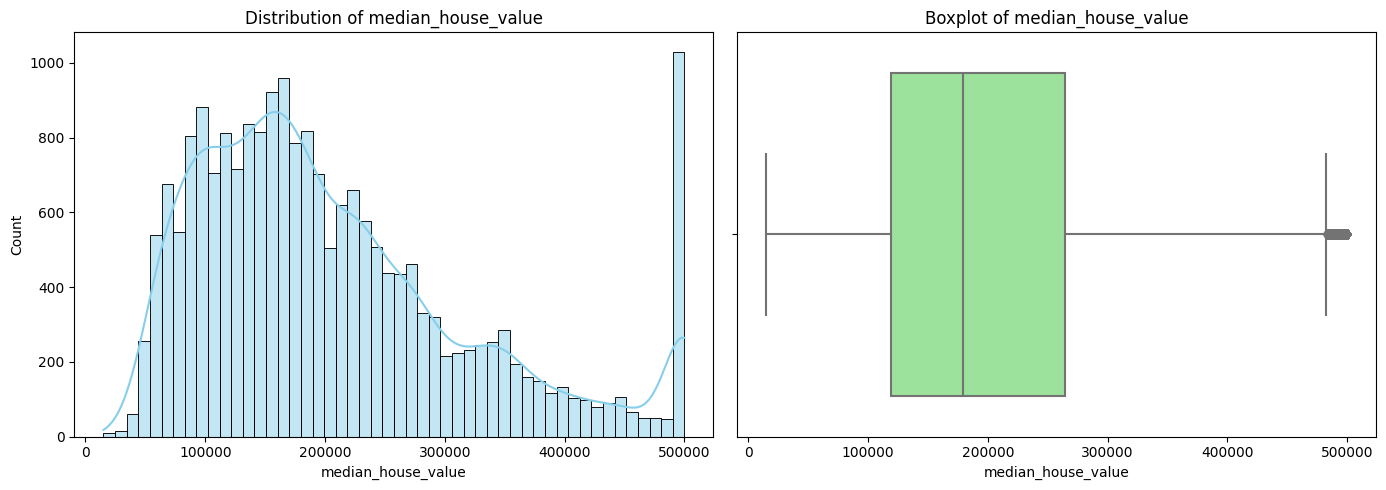

In [ ]:
target_col = 'median_house_value'  

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df[target_col], bins=50, kde=True, color='skyblue')
plt.title(f'Distribution of {target_col}')
plt.xlabel(target_col)
plt.ylabel('Count')

plt.subplot(1,2,2)
sns.boxplot(x=df[target_col], color='lightgreen')
plt.title(f'Boxplot of {target_col}')

plt.tight_layout()
plt.show()

### We have an obvious positive skewness here! And the distribution is far from normal distribution. So we preferred to use IQR method for deleting outliers over Z-score method.

In [ ]:
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_removing_outliers = df.shape[0]

df = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

after_removing_outliers = df.shape[0]

print("\nNumber of records BEFORE removing outliers:", before_removing_outliers)
print("Number of records AFTER removing outliers:", after_removing_outliers)


Number of records BEFORE removing outliers: 20640
Number of records AFTER removing outliers: 19569


## Handle categorical features

In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index(['ocean_proximity'], dtype='object')


### As we see, the only categorical column is *ocean_proximity*!

In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nColumns after encoding:")
print(df.columns)


Columns after encoding:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


# Part 3-2 : Implementing a simple neural network

### Split the dataset

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col].values

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (15655, 12)
X_val shape: (1957, 12)
X_test shape: (1957, 12)


In [ ]:
input_size = X_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_size,)),      
    layers.Dense(8),                        
    layers.ReLU(),                           
    layers.Dense(1)                          
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.1),
    loss='mse'
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

# Part 3-3 : Train the simple neural network

### Define a class for calculating the desired metrics

In [38]:
class RegressionMetrics:
    def __init__(self, y_true, y_pred):
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)

    def mse(self):
        return np.mean((self.y_true - self.y_pred) ** 2)

    def rmse(self):
        return np.sqrt(self.mse())

    def mae(self):
        return np.mean(np.abs(self.y_true - self.y_pred))

    def r2(self):
        ss_res = np.sum((self.y_true - self.y_pred) ** 2)    
        ss_tot = np.sum((self.y_true - np.mean(self.y_true)) ** 2)
        return 1 - (ss_res / ss_tot)


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
onehot_cols = [col for col in df.columns if 'ocean_proximity_' in col]

numeric_cols = [col for col in numeric_cols if col not in onehot_cols and col != 'median_house_value']

print("Numeric columns to normalize:", numeric_cols)
print("Categorical columns to keep as-is:", onehot_cols)

ct = ColumnTransformer([
    ('scale_numeric', StandardScaler(), numeric_cols)
], remainder='passthrough')

X_train_scaled = ct.fit_transform(X_train)
X_val_scaled   = ct.transform(X_val)
X_test_scaled  = ct.transform(X_test)

Numeric columns to normalize: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical columns to keep as-is: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 44496572416.0000 - val_loss: 35797004288.0000
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 31398557696.0000 - val_loss: 19680243712.0000
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16635264000.0000 - val_loss: 11229772800.0000
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9956089856.0000 - val_loss: 8714414080.0000
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7631326720.0000 - val_loss: 7591415808.0000
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6781736960.0000 - val_loss: 6723846656.0000
Epoch 7/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6141297664.0000 - val_loss: 5939405824.0000
Epoch 8/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5242589184.0000 - val_loss: 5311003136.0000
Epoch 9/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4825181184.0000 - val_loss: 4824172544.0000
Epoch 10/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - los

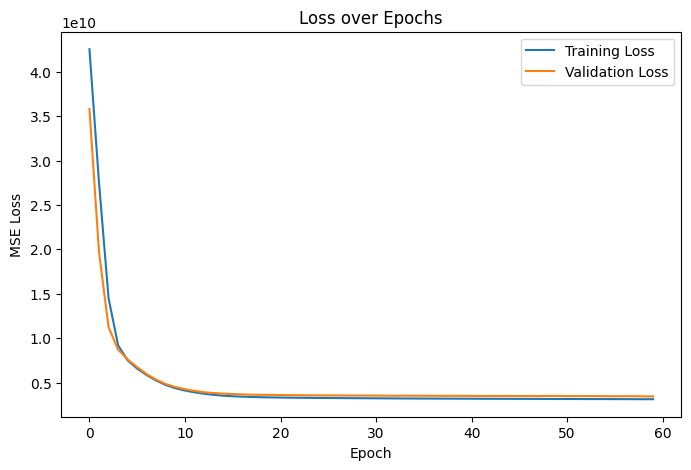

490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Train Metrics:
  MSE  = 3113632201.2904
  RMSE = 55799.9301
  MAE  = 40364.4802
  R2   = 0.6579

Validation Metrics:
  MSE  = 3437378450.7101
  RMSE = 58629.1604
  MAE  = 40931.3304
  R2   = 0.6155

Test Metrics:
  MSE  = 3044705104.1831
  RMSE = 55178.8465
  MAE  = 40418.3120
  R2   = 0.6733


In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=64,
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


y_train_pred = model.predict(X_train_scaled).flatten()
y_val_pred   = model.predict(X_val_scaled).flatten()
y_test_pred  = model.predict(X_test_scaled).flatten()


metrics = {
    "Train": RegressionMetrics(y_train, y_train_pred),
    "Validation": RegressionMetrics(y_val, y_val_pred),
    "Test": RegressionMetrics(y_test, y_test_pred),
}

for name, m in metrics.items():
    print(f"\n{name} Metrics:")
    print(f"  MSE  = {m.mse():.4f}")
    print(f"  RMSE = {m.rmse():.4f}")
    print(f"  MAE  = {m.mae():.4f}")
    print(f"  R2   = {m.r2():.4f}")

# Part 3-4 : Implement and Train a more complex neural network

In [ ]:
input_size = X_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_size,)),

    layers.Dense(128, activation='relu'),          
    layers.BatchNormalization(),                   
    layers.Dropout(0.3),                           

    layers.Dense(64, activation='relu'),           
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),          
    layers.BatchNormalization(),

    layers.Dense(1)                                
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.1),
    loss='mse'
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,481 (48.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
onehot_cols = [col for col in df.columns if 'ocean_proximity_' in col]
numeric_cols = [col for col in numeric_cols if col not in onehot_cols and col != 'median_house_value']

print("Numeric columns to normalize:", numeric_cols)
print("Categorical columns to keep as-is:", onehot_cols)

ct = ColumnTransformer([
    ('scale_numeric', StandardScaler(), numeric_cols)
], remainder='passthrough')

X_train_scaled = ct.fit_transform(X_train)
X_val_scaled   = ct.transform(X_val)
X_test_scaled  = ct.transform(X_test)

Numeric columns to normalize: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical columns to keep as-is: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 43771678720.0000 - val_loss: 29746704384.0000
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19798519808.0000 - val_loss: 9615848448.0000
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5069404160.0000 - val_loss: 3411973888.0000
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3011283456.0000 - val_loss: 2946183936.0000
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2907344896.0000 - val_loss: 2885484288.0000
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2987097856.0000 - val_loss: 2783083776.0000
Epoch 7/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2842635776.0000 - val_loss: 2758838272.0000
Epoch 8/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2833991680.0000 - val_loss: 2729540352.0000
Epoch 9/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2841310208.0000 - val_loss: 2626126592.0000
Epoch 10/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 

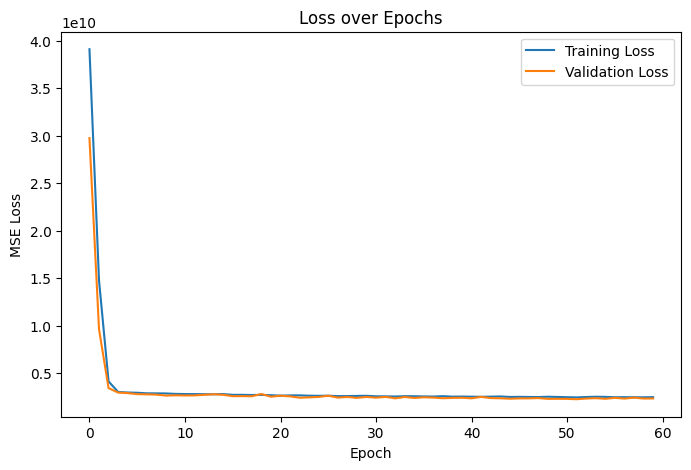

490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Train Metrics:
  MSE  = 2049163130.7108
  RMSE = 45267.6831
  MAE  = 31380.7404
  R2   = 0.7749

Validation Metrics:
  MSE  = 2325304085.8537
  RMSE = 48221.4069
  MAE  = 32701.4435
  R2   = 0.7399

Test Metrics:
  MSE  = 2167109152.4674
  RMSE = 46552.2196
  MAE  = 32356.9023
  R2   = 0.7675


In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=64,
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


y_train_pred = model.predict(X_train_scaled).flatten()
y_val_pred   = model.predict(X_val_scaled).flatten()
y_test_pred  = model.predict(X_test_scaled).flatten()


metrics = {
    "Train": RegressionMetrics(y_train, y_train_pred),
    "Validation": RegressionMetrics(y_val, y_val_pred),
    "Test": RegressionMetrics(y_test, y_test_pred),
}

for name, m in metrics.items():
    print(f"\n{name} Metrics:")
    print(f"  MSE  = {m.mse():.4f}")
    print(f"  RMSE = {m.rmse():.4f}")
    print(f"  MAE  = {m.mae():.4f}")
    print(f"  R2   = {m.r2():.4f}")

# Part 3-5 : Comparison

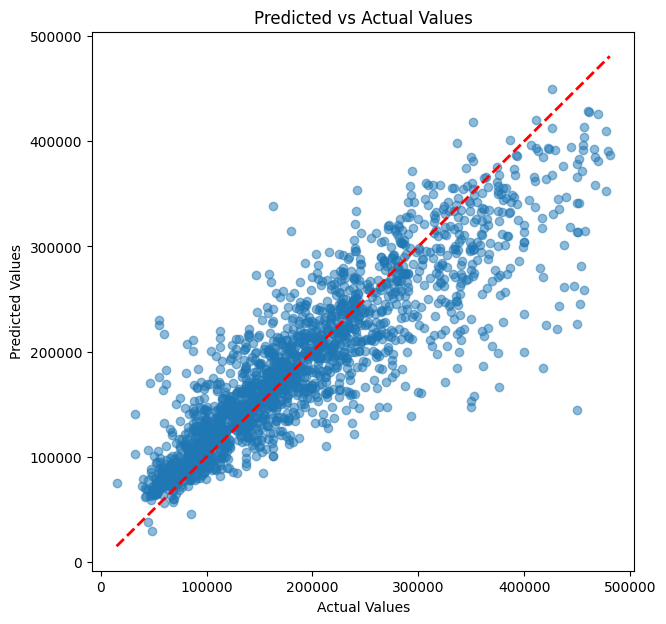

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)  
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.show()